In [8]:
import scanpy as sc
print(sc.__version__)

1.11.5


C:\Users\marga\AppData\Local\Temp\ipykernel_8252\289967954.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [9]:
import scanpy as sc

adata = sc.read_h5ad("../input_data/decidua.h5ad")
adata

AnnData object with n_obs × n_vars = 70325 × 31764
    obs: 'CellType', 'Fetus', 'Location', 'nGene', 'nUMI', 'percent.mito'
    obsm: 'UMAP'

In [10]:
adata.obs.columns

Index(['CellType', 'Fetus', 'Location', 'nGene', 'nUMI', 'percent.mito'], dtype='object')

In [11]:
adata.obs["CellType"].value_counts()

CellType
Tcells          10833
VCT              9479
dS1              7261
dNK2             5661
dS2              4760
dNK1             4047
EVT              3626
dM1              3473
dM2              3006
dNK3             2219
fFB1             2188
NK CD16+         1591
HB               1372
SCT              1261
MO               1227
dP1              1081
dS3               938
dM3               930
Endo (m)          917
dP2               841
dNK p             777
Plasma            367
DC1               359
DC2               354
Endo L            350
Granulocytes      269
NK CD16-          263
Epi1              226
ILC3              220
Epi2              216
fFB2              113
Endo (f)          100
Name: count, dtype: int64

Trophoblast:
VCT, EVT, SCT

Immune receivers:
Tcells
dNK1, dNK2, dNK3, dNK p
dM1, dM2, dM3
DC1, DC2, MO, Plasma, ILC3

| Trophoblast state | Core markers | Supportive markers | Notes                                                |
| ----------------- | ------------ | ------------------ | ---------------------------------------------------- |
| EVT               | HLA-G        | ITGA5, ERBB2       | Invasive extravillous trophoblast-associated program |
| SCT               | CGA, CGB     | LGALS16            | Syncytial/endocrine trophoblast program              |
| VCT               | KRT7, EGFR   | —                  | Villous epithelial/progenitor trophoblast state      |



In [12]:
tropho = adata[adata.obs["CellType"].isin(["VCT", "EVT", "SCT"])].copy()

immune_core = adata[
    adata.obs["CellType"].isin([
        "Tcells", "dNK1", "dNK2", "dNK3", "dNK p", "dM1", "dM2", "dM3"
    ])
].copy()


In [13]:
#get proper gene name
##[g for g in adata.var_names if "HLA" in g][:50]
# so they start with a few patterns HHLA2_ENSG00000114455 etc
for term in ["HLA-G", "ITGA5", "ERBB2", "LGALS16", "CGA", "CGB", "KRT7"]:
    print(term, [g for g in adata.var_names if g.startswith(term + "_")])

HLA-G ['HLA-G_ENSG00000204632']
ITGA5 ['ITGA5_ENSG00000161638']
ERBB2 ['ERBB2_ENSG00000141736']
LGALS16 ['LGALS16_ENSG00000249861']
CGA ['CGA_ENSG00000135346']
CGB ['CGB_ENSG00000104827']
KRT7 ['KRT7_ENSG00000135480']


In [14]:
def find_gene(symbol):
    matches = [g for g in adata.var_names if g.startswith(symbol + "_")]
    if len(matches) == 0:
        print(f"No match for {symbol}")
        return None
    if len(matches) > 1:
        print(f"Multiple matches for {symbol}: {matches}")
    return matches[0]

genes = [find_gene(g) for g in ["HLA-G", "ITGA5", "ERBB2", "LGALS16", "CGA", "CGB", "KRT7"]]
genes

['HLA-G_ENSG00000204632',
 'ITGA5_ENSG00000161638',
 'ERBB2_ENSG00000141736',
 'LGALS16_ENSG00000249861',
 'CGA_ENSG00000135346',
 'CGB_ENSG00000104827',
 'KRT7_ENSG00000135480']

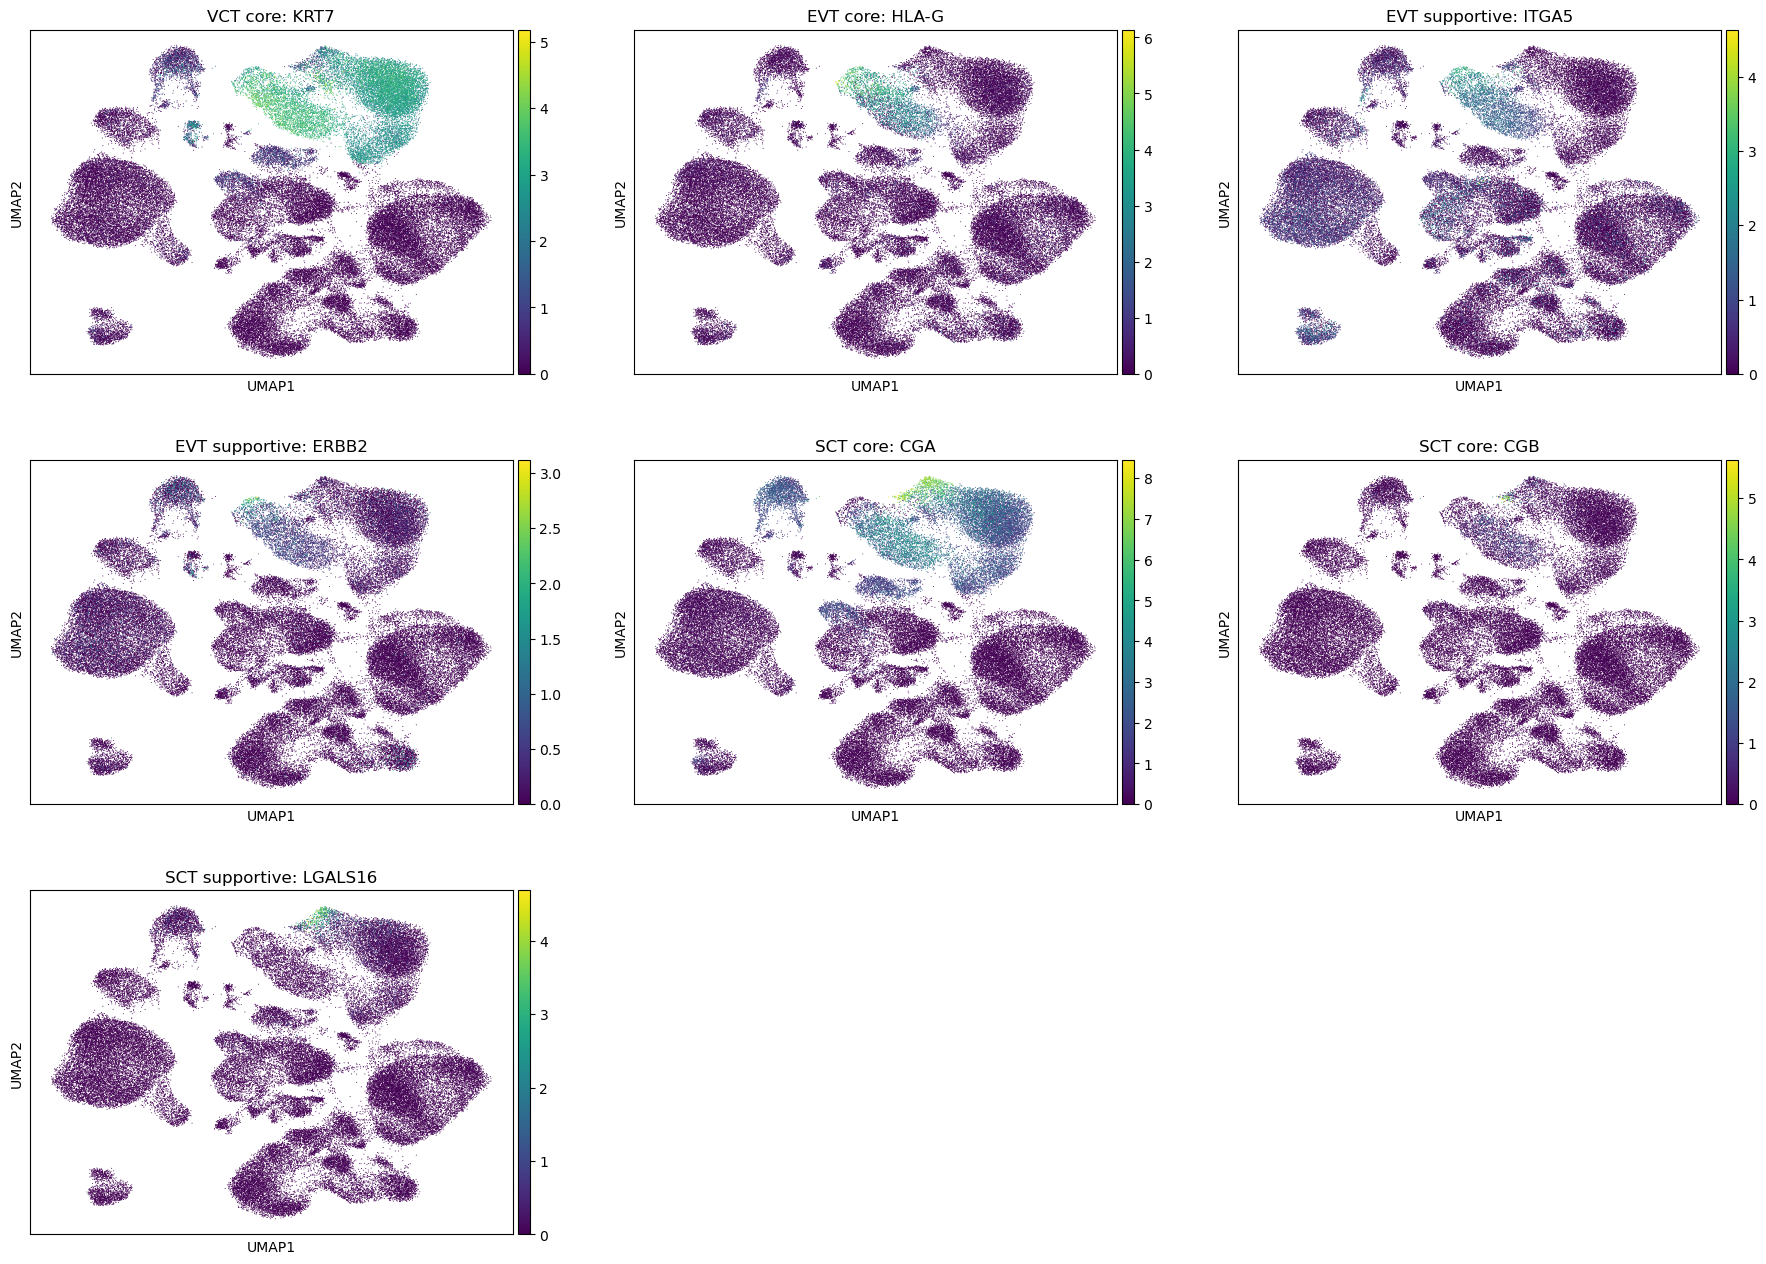

In [15]:
import scanpy as sc
import matplotlib.pyplot as plt

marker_panels = {
    "VCT core: KRT7": "KRT7_ENSG00000135480",
    "EVT core: HLA-G": "HLA-G_ENSG00000204632",
    "EVT supportive: ITGA5": "ITGA5_ENSG00000161638",
    "EVT supportive: ERBB2": "ERBB2_ENSG00000141736",
    "SCT core: CGA": "CGA_ENSG00000135346",
    "SCT core: CGB": "CGB_ENSG00000104827",
    "SCT supportive: LGALS16": "LGALS16_ENSG00000249861",
}

genes = list(marker_panels.values())
titles = list(marker_panels.keys())

axes = sc.pl.embedding(
    adata,
    basis="UMAP",
    color=genes,
    ncols=3,
    size=2,
    frameon=True,
    show=False
)

for ax, title in zip(axes, titles):
    ax.set_title(title)

plt.savefig(
    "../figures/trophoblast_marker_umaps.png",
    dpi=300,
    bbox_inches="tight"
)

UMAP interpretation
The UMAP shows discrete annotated cell populations, but marker expression reveals
structure within the trophoblast compartment. EVT, SCT, and VCT occupy distinct regions, and canonical marker expression aligns with these annotations. This supports using the provided labels as a starting point while also interpreting trophoblast markers as 'state scores' rather than  treating clusters as perfectly binary.

Second sanity check:

VCT == villous cytotrophoblast, a proliferative/progenitor epithelial trophoblast
so expect it to be rich in: epithelial markers, trophoblast identity markers, proliferation-associated programs

EVT == extravillous trophoblast, an invasive interface-engaging trophoblast
so expect it to be rich in: invasion machinery, adhesion remodeling, immune tolerance signaling

SCT == syncytiotrophoblast, a hormone producing outer trophoblast layer
SCT cells mediate endocrine signaling and produce pregnancy hormones
so we expect it to be rich in: hormone genes, fusion/syncytialization programs

Marker genes:
HLA-G - immunomodulatory HLA
CGA / CGB - encode subunits of human chorionic gonadotropin (hCG)
KRT7 - pan trophoblast marker

Expected pattern:
SCT: CGA/CGB high
EVT: HLA-G high
VCT: KRT7 high, lower HLA-G/CGA/CGB


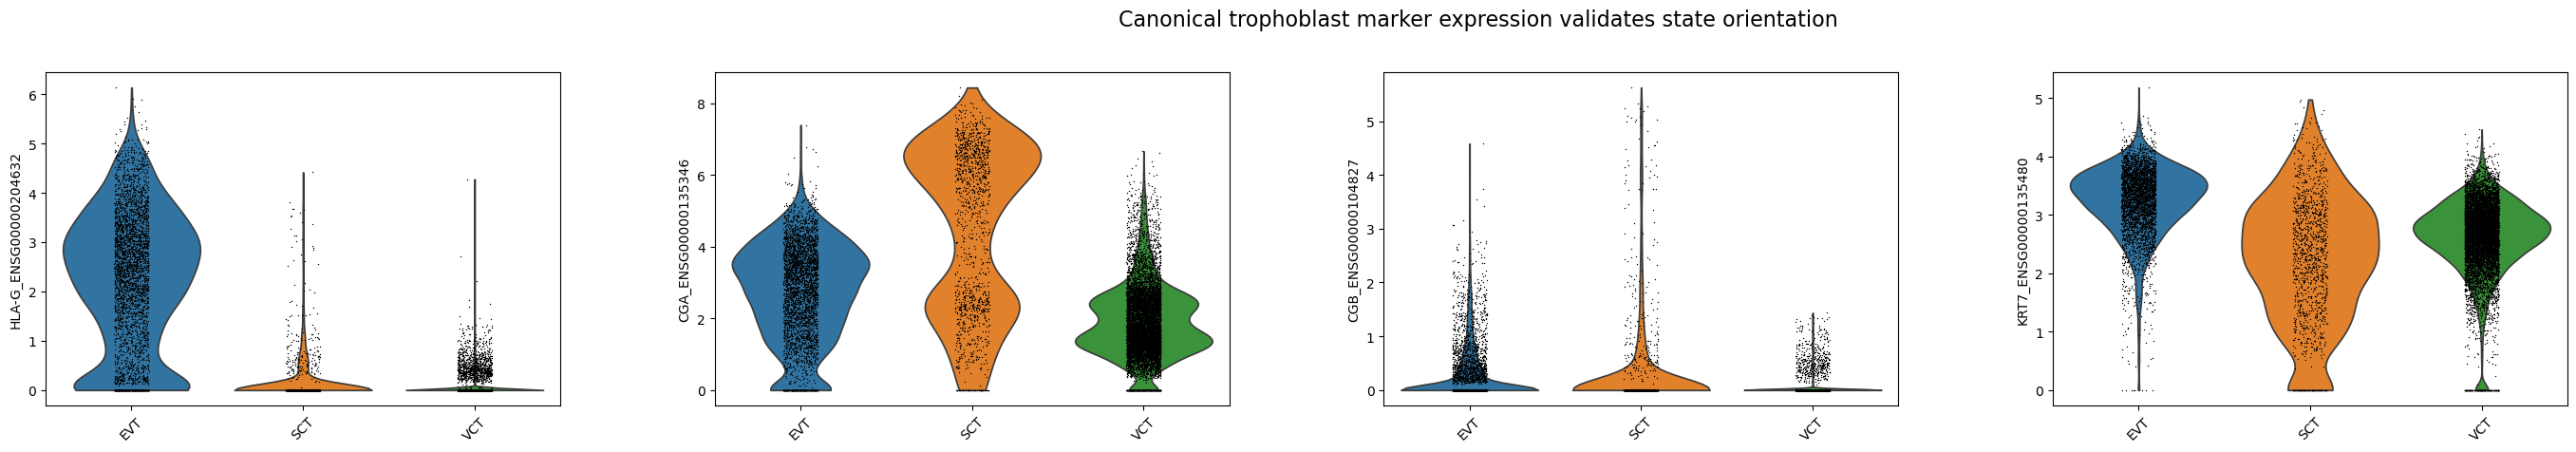

In [16]:
import matplotlib.pyplot as plt

sc.pl.violin(
    tropho,
    keys=[
        "HLA-G_ENSG00000204632",
        "CGA_ENSG00000135346",
        "CGB_ENSG00000104827",
        "KRT7_ENSG00000135480"
    ],
    groupby="CellType",
    rotation=45,
    show=False
)

plt.suptitle(
    "Canonical trophoblast marker expression validates state orientation",
    fontsize=16,
    y=1.02
)

plt.savefig(
    "../figures/trophoblast_marker_violins.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The trophoblast annotations behave as expected.
HLA-G expression is concentrated in EVT, consistent with an extravillous/interface-engaged trophoblast identity. CGA and CGB are enriched in SCT, consistent with syncytiotrophoblast endocrine/hCG-producing identity.
KRT7 is broadly expressed across trophoblast populations, supporting its use as a pan-trophoblast epithelial marker rather than a state-specific marker.

These plots establish that the dataset is suitable for a state-aware trophoblast analysis: EVT is marked by HLA-G-high invasive/interface biology, SCT by CGA/CGB-high endocrine syncytial biology, and VCT by broader trophoblast epithelial identity. This provides the foundation for asking whether trophoblast state is associated with distinct immune- regulatory ligand programs.

Next we build a clean trophoblast-only object and define interpretable trophoblast state scores


In [17]:
 #helper for this dataset's SYMBOL_ENSG gene names
def find_gene(symbol, adata=adata):
    matches = [g for g in adata.var_names if g.startswith(symbol + "_")]
    if len(matches) == 0:
        print(f"No match: {symbol}")
        return None
    if len(matches) > 1:
        print(f"Multiple matches for {symbol}: {matches}")
    return matches[0]


In [18]:
#subset trophoblasts
tropho = adata[adata.obs["CellType"].isin(["VCT", "EVT", "SCT"])].copy()
tropho


AnnData object with n_obs × n_vars = 14366 × 31764
    obs: 'CellType', 'Fetus', 'Location', 'nGene', 'nUMI', 'percent.mito'
    obsm: 'UMAP'

Initial trophoblast state programs were seeded from markers recurrently used in first-trimester human placental single-cell atlases, particularly Vento-Tormo et al. 2018 first-trimester placenta atlas, which profiled the maternal–fetal interface in vivo. These programs were selected to capture broad biological states rather than strict binary cell identities. 

The EVT/invasion program (HLA-G, ITGA1, MMP2, FN1, ASCL2) was designed to capture invasive and interface-engaged trophoblast biology. HLA-G is a canonical EVT-associated immunomodulatory molecule linked to maternal immune tolerance at the decidual interface. ITGA1, MMP2, and FN1 reflect extracellular matrix interaction and tissue remodeling programs associated with trophoblast invasion, while ASCL2 has been linked to trophoblast lineage specification and invasive trophoblast identity.

The SCT/syncytial program (CGA, CGB, SDC1, ERVFRD-1, LGALS16, GDF15) was designed to capture differentiated syncytiotrophoblast/endocrine biology. CGA and CGB encode subunits of hCG and are canonical syncytiotrophoblast markers. ERVFRD-1 (syncytin-2) is associated with trophoblast fusion, while SDC1, LGALS16, and GDF15 are recurrently associated with placental endocrine and differentiated syncytial states.

The VCT/progenitor program (KRT7, TEAD4, TP63) was designed to capture broader trophoblast epithelial and progenitor-associated identity. KRT7 is commonly used as a pan-trophoblast epithelial marker, while TEAD4 and TP63 are associated with developmental and less differentiated trophoblast states.

In [19]:
programs = {
    "invasion_evt": ["HLA-G", "ITGA1", "MMP2", "FN1", "ASCL2"],
    "syncytial_sct": ["CGA", "CGB", "SDC1", "ERVFRD-1", "LGALS16", "GDF15"],
    "progenitor_vct": ["KRT7", "TEAD4", "TP63"],
}


In [20]:
#Convert to dataset-specific names and drop missing genes:
programs_found = {}

for program, symbols in programs.items():
    genes = [find_gene(g) for g in symbols]
    genes = [g for g in genes if g is not None]
    programs_found[program] = genes
    print(program, genes)


invasion_evt ['HLA-G_ENSG00000204632', 'ITGA1_ENSG00000213949', 'MMP2_ENSG00000087245', 'FN1_ENSG00000115414', 'ASCL2_ENSG00000183734']
syncytial_sct ['CGA_ENSG00000135346', 'CGB_ENSG00000104827', 'SDC1_ENSG00000115884', 'ERVFRD-1_ENSG00000244476', 'LGALS16_ENSG00000249861', 'GDF15_ENSG00000130513']
progenitor_vct ['KRT7_ENSG00000135480', 'TEAD4_ENSG00000197905', 'TP63_ENSG00000073282']


Gene program scores are computed using Scanpy’s score_genes function. For each cell, this computes the average expression of genes in a curated program relative to a matched control set of genes sampled from similar expression bins. Scores were interpreted as relative enrichment of a transcriptional program, not as direct measurements of pathway activity or functional signaling.

We score programs and not genes because single cell data is noisy in a way that bulk isn't (bulk being noisy in a different way)

i.e we have
dropout and cell-cycle/state noise in addition to sequencing depth variation and stochastic expression 

A program score is more robust because it averages signal across multiple genes.

In [21]:
#score programs
for program, genes in programs_found.items():
    sc.tl.score_genes(
        tropho,
        gene_list=genes,
        score_name=f"{program}_score"
    )


Expected behavior:
EVT high: invasion_evt_score
SCT high: syncytial_sct_score
VCT high-ish: progenitor_vct_score


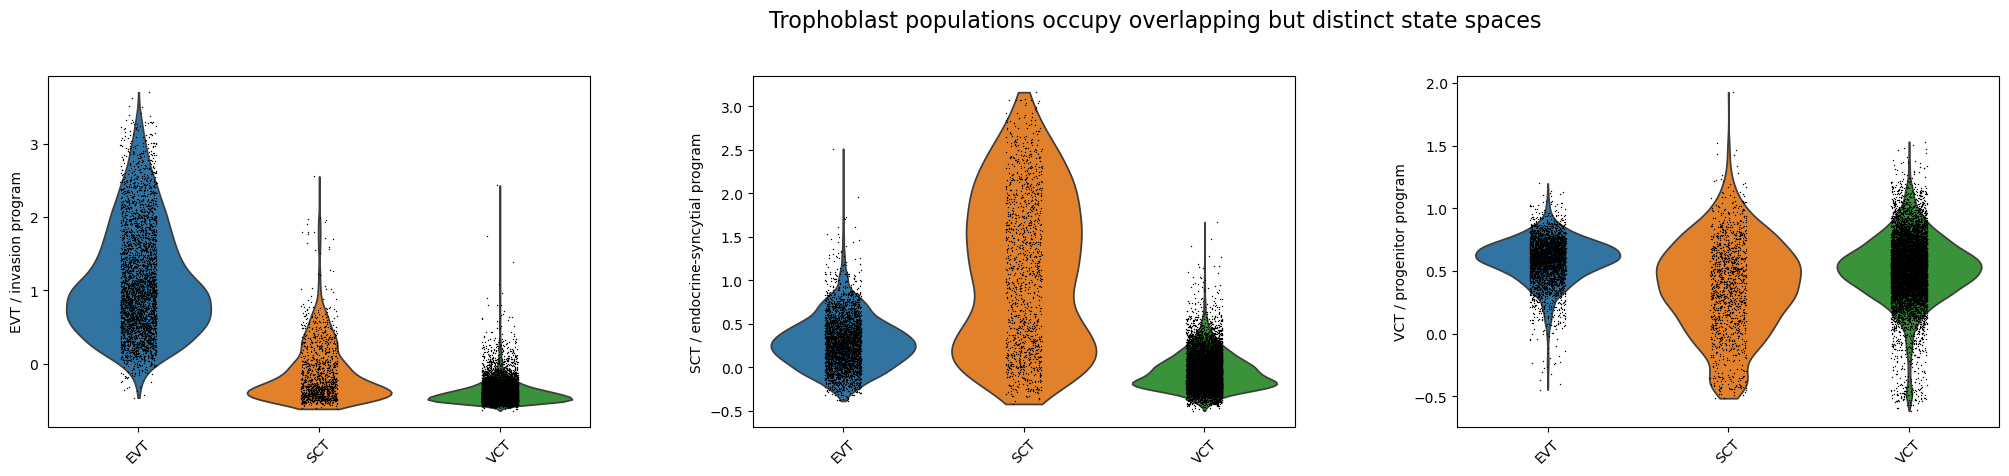

In [22]:
tropho.obs["EVT / invasion program"] = tropho.obs["invasion_evt_score"]
tropho.obs["SCT / endocrine-syncytial program"] = tropho.obs["syncytial_sct_score"]
tropho.obs["VCT / progenitor program"] = tropho.obs["progenitor_vct_score"]

sc.pl.violin(
    tropho,
    keys=[
        "EVT / invasion program",
        "SCT / endocrine-syncytial program",
        "VCT / progenitor program"
    ],
    groupby="CellType",
    rotation=45,
    multi_panel=True,
    show=False
)

plt.suptitle(
    "Trophoblast populations occupy overlapping but distinct state spaces",
    fontsize=16,
    y=1.02
)

plt.savefig(
    "../figures/trophoblast_programs_violins.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


trophoblast populations occupy distinct but partially overlapping state spaces, with EVT and SCT showing strong enrichment for invasion-associated and syncytial/endocrine programs, respectively, while VCT retains a broader progenitor-like profile. VCT heterogeneity is unsurprising


To test whether trophoblast states differ in immune-regulatory signaling potential, I scored curated ligand programs within trophoblast cells. These scores are interpreted as relative enrichment of ligand-associated transcriptional programs, not direct evidence of ligand secretion or functional receptor engagement. Comparing these scores across EVT, SCT, and VCT provides a first-pass test of whether immune-directed signaling potential is state-associated within the trophoblast compartment.


Ligand programs were refined using a combination of maternal–fetal interface literature, trophoblast-focused immunology studies, and manual review of reported trophoblast expression patterns. Genes were prioritized based on evidence for trophoblast-associated expression in vivo, particularly within EVT or interface-engaged trophoblast populations, while broadly disease-specific or tumor-derived immune signatures were deprioritized.

Programs were organized into biologically interpretable categories representing distinct modes of immune regulation at the maternal–fetal interface, including checkpoint/inhibitory signaling, nonclassical HLA-mediated tolerance, chemokine-mediated immune organization, apoptotic immune privilege, and broader cytokine/metabolic conditioning programs.

Importantly, these programs are intentionally small and biologically constrained. This reflects both the limited number of well-supported trophoblast-associated immunoregulatory ligands and the desire to maintain mechanistic interpretability rather than maximize gene set size. Program scores should therefore be interpreted as relative enrichment of curated trophoblast-associated signaling modules rather than comprehensive measurements of immune signaling capacity.

Several included genes are not trophoblast-exclusive and may also be expressed in stromal, immune, or endothelial populations. Accordingly, interpretation focuses on relative enrichment patterns within annotated trophoblast populations rather than absolute trophoblast specificity.

These scores are interpreted as relative enrichment of ligand-associated transcriptional programs, not direct evidence of ligand secretion or functional receptor engagement. Comparing these scores across EVT, SCT, and VCT provides a first-pass test of whether immune-directed signaling potential is state-associated within the trophoblast compartment.





In [23]:
ligand_programs = {

    # Checkpoint / inhibitory signaling
    "checkpoint_inhibitory": [
        "CD274",
        "CD200",
        "CD276"
    ],

    # Canonical EVT tolerance biology
    "nonclassical_hla_tolerance": [
        "HLA-G",
        "HLA-E",
        "HLA-F",
        "HLA-C"
    ],

    # Chemokine-mediated immune recruitment / organization
    "chemokine_recruitment": [
        "CCL2",
        "CXCL16",
        "CXCL8"
    ],

    # Apoptotic immune privilege
    "apoptotic_privilege": [
        "FASLG",
        "TNFSF10"
    ],

    # Cytokine / metabolic conditioning
    "cytokine_conditioning": [
        "TGFB1",
        "CSF1"
    ]
}

In [24]:
ligand_programs_found = {}

for program, symbols in ligand_programs.items():
    genes = [find_gene(g) for g in symbols]
    genes = [g for g in genes if g is not None]

    ligand_programs_found[program] = genes

    print(program)
    print(genes)
    print()

checkpoint_inhibitory
['CD274_ENSG00000120217', 'CD200_ENSG00000091972', 'CD276_ENSG00000103855']

nonclassical_hla_tolerance
['HLA-G_ENSG00000204632', 'HLA-E_ENSG00000204592', 'HLA-F_ENSG00000204642', 'HLA-C_ENSG00000204525']

chemokine_recruitment
['CCL2_ENSG00000108691', 'CXCL16_ENSG00000161921', 'CXCL8_ENSG00000169429']

apoptotic_privilege
['FASLG_ENSG00000117560', 'TNFSF10_ENSG00000121858']

cytokine_conditioning
['TGFB1_ENSG00000105329', 'CSF1_ENSG00000184371']



In [25]:
for program, genes in ligand_programs_found.items():

    if len(genes) >= 2:

        sc.tl.score_genes(
            tropho,
            gene_list=genes,
            score_name=f"{program}_score"
        )

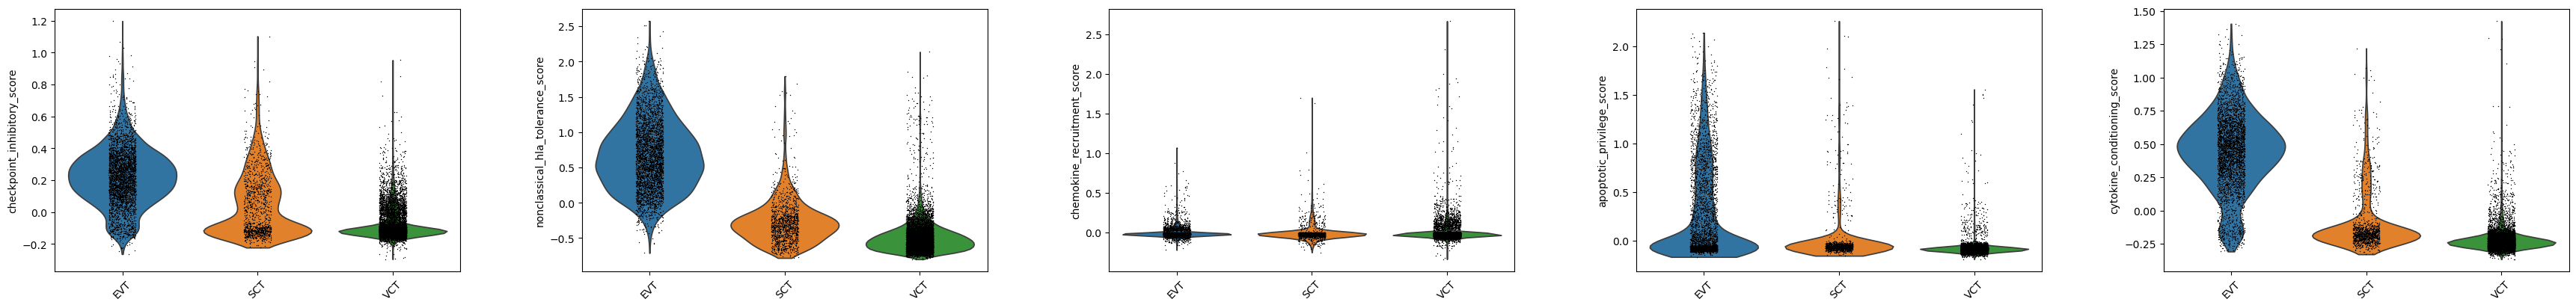

In [26]:
sc.pl.violin(
    tropho,
    keys=[
        f"{p}_score"
        for p in ligand_programs_found.keys()
        if len(ligand_programs_found[p]) >= 2
    ],
    groupby="CellType",
    rotation=45,
    multi_panel=True
)

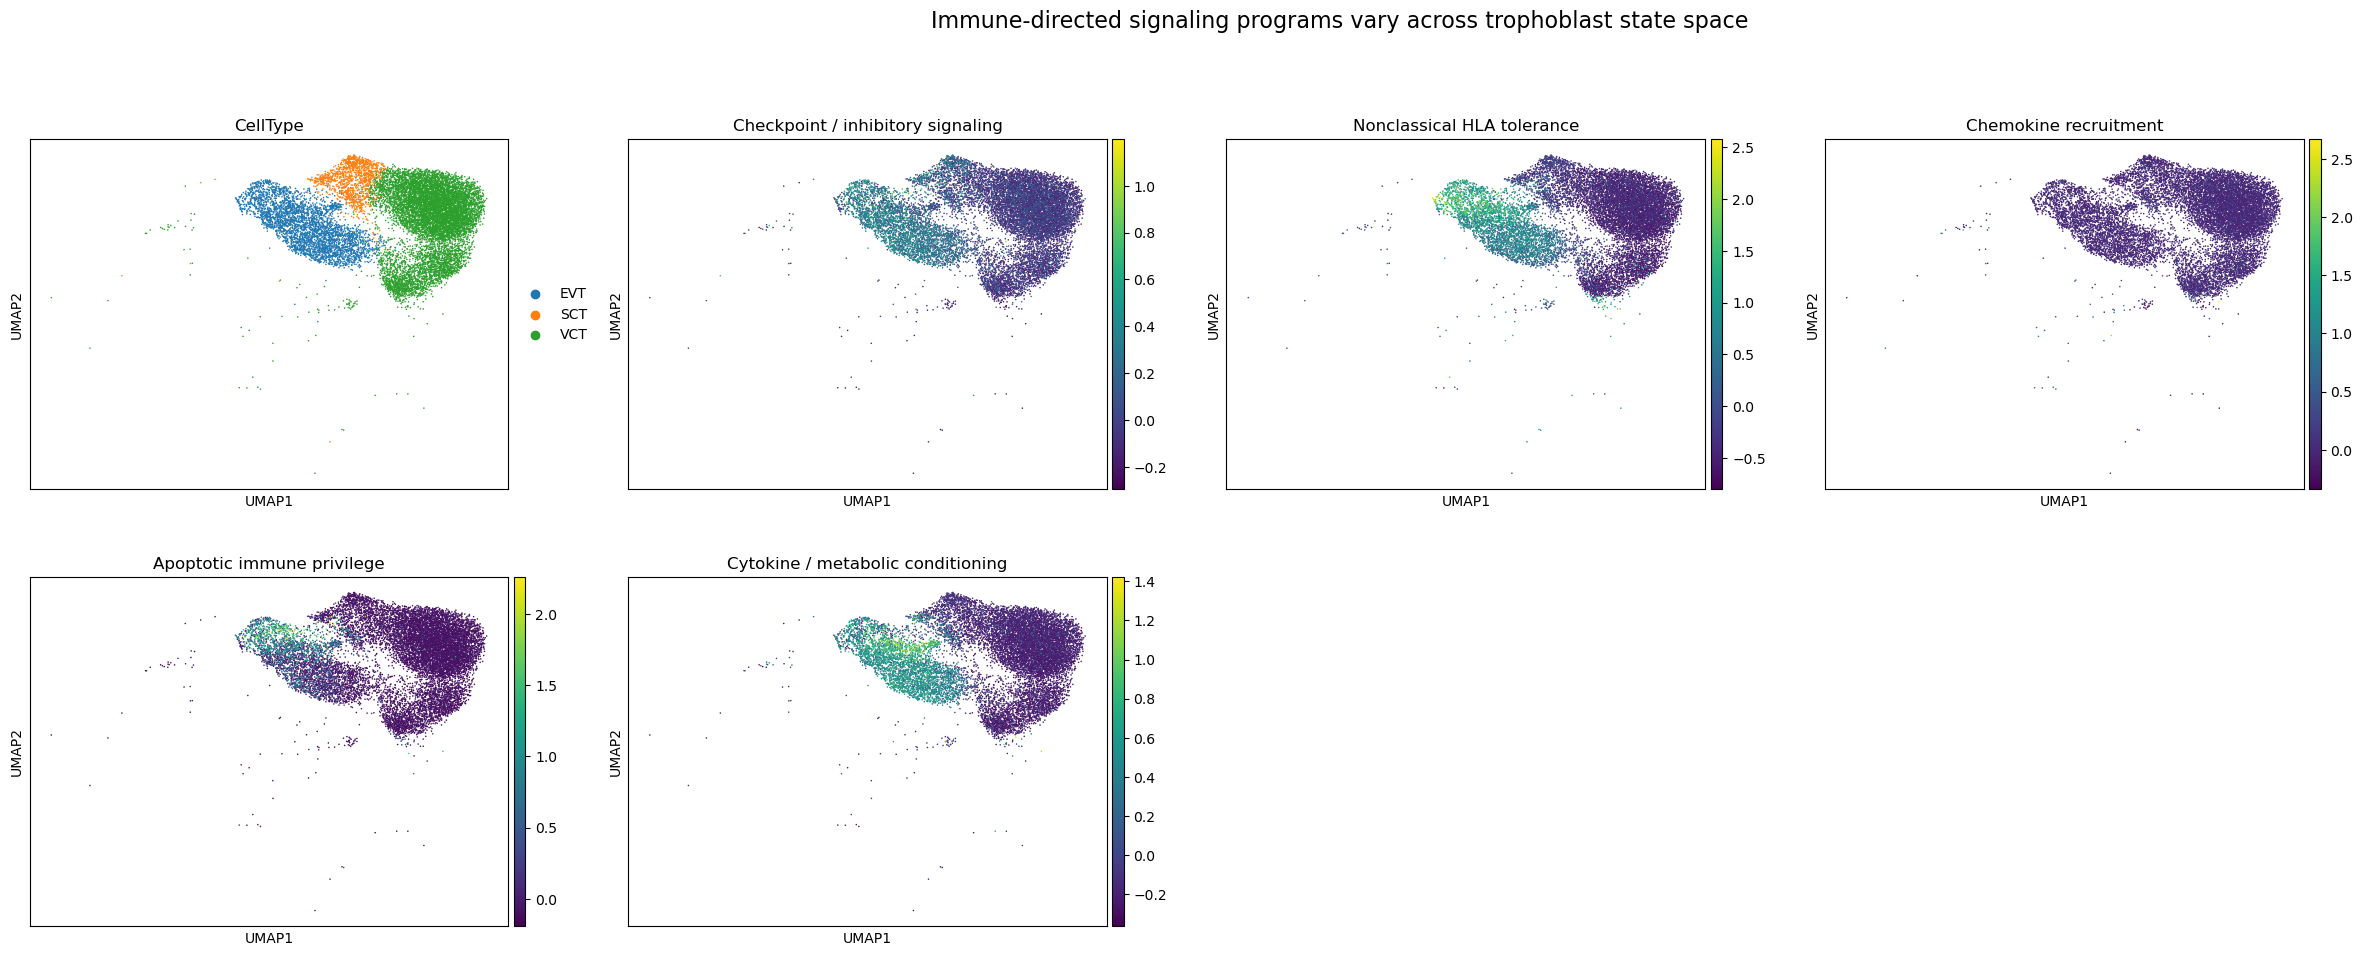

In [27]:
# prettier display names for README figures
tropho.obs["Checkpoint / inhibitory signaling"] = tropho.obs["checkpoint_inhibitory_score"]

tropho.obs["Nonclassical HLA tolerance"] = tropho.obs["nonclassical_hla_tolerance_score"]

tropho.obs["Chemokine recruitment"] = tropho.obs["chemokine_recruitment_score"]

tropho.obs["Apoptotic immune privilege"] = tropho.obs["apoptotic_privilege_score"]

tropho.obs["Cytokine / metabolic conditioning"] = tropho.obs["cytokine_conditioning_score"]


sc.pl.embedding(
    tropho,
    basis="UMAP",
    color=[
        "CellType",

        "Checkpoint / inhibitory signaling",
        "Nonclassical HLA tolerance",
        "Chemokine recruitment",
        "Apoptotic immune privilege",
        "Cytokine / metabolic conditioning"
    ],
    size=5,
    show=False
)

plt.suptitle(
    "Immune-directed signaling programs vary across trophoblast state space",
    fontsize=16,
    y=1.02
)

plt.savefig(
    "../figures/trophoblast_immune_program_umaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Projection of ligand-program scores onto the trophoblast UMAP shows state-associated enrichment without collapsing all cells into binary positive/negative groups. Nonclassical HLA/tolerance, checkpoint/inhibitory, and cytokine-conditioning programs are enriched along the EVT-associated region, while VCT and SCT remain comparatively lower. Importantly, these scores preserve within-state heterogeneity and do not appear to be driven by isolated off-axis cells, supporting their use as continuous state-associated measures rather than strict categorical labels.

Now we move into asking whether trophoblast states differ in their enriched ligand programs. 

First, for each trophoblast state, we define its enriched ligand programs.
Then, for each immune population, measure expression of cognate receptor programs.
This gives a first-pass estimate of which immune populations are most compatible with signals from VCT-, EVT-, or SCT-like trophoblast states.

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sender trophoblast states
sender_states = ["VCT", "EVT", "SCT"]

# Receiver immune populations
receiver_pops = [
    "Tcells",
    "dNK1", "dNK2", "dNK3", "dNK p",
    "dM1", "dM2", "dM3"
]

tropho = adata[adata.obs["CellType"].isin(sender_states)].copy()
immune = adata[adata.obs["CellType"].isin(receiver_pops)].copy()


In [29]:
sender_states


['VCT', 'EVT', 'SCT']

In [30]:
# Define ligand score columns already created in tropho
ligand_score_cols = [
    "checkpoint_inhibitory_score",
    "nonclassical_hla_tolerance_score",
    "chemokine_recruitment_score",
    "apoptotic_privilege_score",
    "cytokine_conditioning_score"
]

# Check they exist
missing_ligand_scores = [c for c in ligand_score_cols if c not in tropho.obs.columns]
missing_ligand_scores

['checkpoint_inhibitory_score',
 'nonclassical_hla_tolerance_score',
 'chemokine_recruitment_score',
 'apoptotic_privilege_score',
 'cytokine_conditioning_score']

In [31]:
ligand_programs = {
    "checkpoint_inhibitory": ["CD274", "CD200", "CD276"],
    "nonclassical_hla_tolerance": ["HLA-G", "HLA-E", "HLA-F", "HLA-C"],
    "chemokine_recruitment": ["CCL2", "CXCL16", "CXCL8"],
    "apoptotic_privilege": ["FASLG", "TNFSF10"],
    "cytokine_conditioning": ["TGFB1", "CSF1"]
}

ligand_programs_found = {}

for program, symbols in ligand_programs.items():
    genes = [find_gene(g) for g in symbols]
    genes = [g for g in genes if g is not None]
    ligand_programs_found[program] = genes
    print(program, genes)

for program, genes in ligand_programs_found.items():
    if len(genes) >= 2:
        sc.tl.score_genes(
            tropho,
            gene_list=genes,
            score_name=f"{program}_score"
        )

ligand_score_cols = [
    f"{p}_score"
    for p, genes in ligand_programs_found.items()
    if len(genes) >= 2
]



checkpoint_inhibitory ['CD274_ENSG00000120217', 'CD200_ENSG00000091972', 'CD276_ENSG00000103855']
nonclassical_hla_tolerance ['HLA-G_ENSG00000204632', 'HLA-E_ENSG00000204592', 'HLA-F_ENSG00000204642', 'HLA-C_ENSG00000204525']
chemokine_recruitment ['CCL2_ENSG00000108691', 'CXCL16_ENSG00000161921', 'CXCL8_ENSG00000169429']
apoptotic_privilege ['FASLG_ENSG00000117560', 'TNFSF10_ENSG00000121858']
cytokine_conditioning ['TGFB1_ENSG00000105329', 'CSF1_ENSG00000184371']


In [32]:
# Average ligand-program scores by trophoblast sender state
sender_ligand_summary = (
    tropho.obs
    .groupby("CellType")[ligand_score_cols]
    .mean()
    .loc[sender_states]
)

sender_ligand_summary

C:\Users\marga\AppData\Local\Temp\ipykernel_8252\3335106227.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("CellType")[ligand_score_cols]


,checkpoint_inhibitory_score,nonclassical_hla_tolerance_score,chemokine_recruitment_score,apoptotic_privilege_score,cytokine_conditioning_score
CellType,,,,,
VCT,-0.079895,-0.487937,-0.003401,-0.082486,-0.220961
EVT,0.219902,0.684984,-0.001740,0.279040,0.443171
SCT,0.047363,-0.261756,-0.001446,0.004269,-0.092048


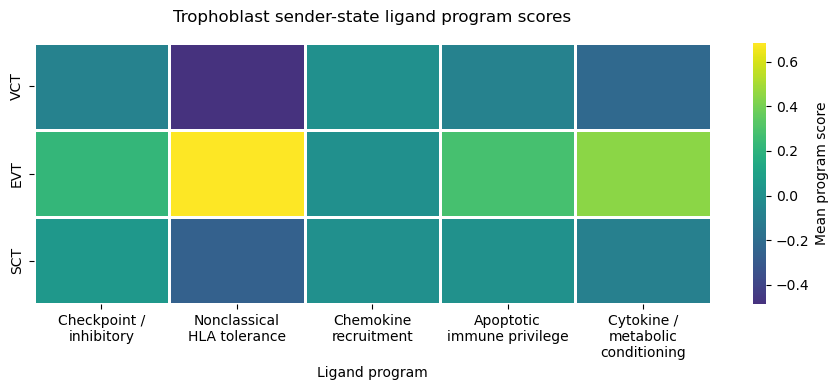

In [61]:
plot_df = sender_ligand_summary.copy()

plot_df = plot_df.rename(
    columns={
        "checkpoint_inhibitory_score":
            "Checkpoint /\ninhibitory",

        "nonclassical_hla_tolerance_score":
            "Nonclassical\nHLA tolerance",

        "chemokine_recruitment_score":
            "Chemokine\nrecruitment",

        "apoptotic_privilege_score":
            "Apoptotic\nimmune privilege",

        "cytokine_conditioning_score":
            "Cytokine /\nmetabolic\nconditioning"
    }
)

plot_df.index.name = "Trophoblast sender state"

plt.figure(figsize=(9,4))

sns.heatmap(
    plot_df,
    cmap="viridis",
    center=0,
    linewidths=1,
    cbar_kws={"label":"Mean program score"}
)

plt.title(
    "Trophoblast sender-state ligand program scores",
    pad=15
)

plt.xlabel("Ligand program")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "../figures/trophoblast_sender_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
import os
os.getcwd()

'c:\\Users\\marga\\Desktop\\state_project\\notebooks'

In [65]:
import os
os.rename("../gitignore", "../.gitignore")

Receiver-side programs were designed to represent immune-cell responsiveness or signaling competency states rather than direct evidence of active ligand–receptor engagement. These programs therefore capture the potential capacity of immune populations to interpret trophoblast-derived signals within the maternal–fetal interface environment.

In [34]:
receptor_programs = {

    "nk_hla_tolerance_receptors": [
        "LILRB1",
        "LILRB2",
        "KLRD1",
        "KLRC1",
        "KIR2DL1",
        "KIR2DL2",
        "KIR2DL3",
        "KIR2DL4",
        "KIR2DS1"
    ],

    "nk_activation_receptors": [
        "NCR1",
        "NCR3",
        "KLRK1",
        "CD244",
        "FCGR3A",
        "KLRB1"
    ],

    "tcell_checkpoint_receptors": [
        "PDCD1",
        "TIGIT",
        "HAVCR2"
    ],

    "treg_tolerance_receptors": [
        "IL2RA",
        "CTLA4",
        "TIGIT",
        "TNFRSF18",
        "TNFRSF4",
        "ICOS"
    ],

    "chemokine_receiver_receptors": [
        "CCR1",
        "CCR2",
        "CCR5",
        "CXCR3",
        "CXCR4",
        "CX3CR1"
    ],

    "macrophage_conditioning_receptors": [
        "CSF1R",
        "TGFBR1",
        "TGFBR2",
        "IL10RA",
        "IL10RB"
    ]
}

In [35]:
# Convert receptor symbols to dataset-specific var names
receptor_programs_found = {}

for program, symbols in receptor_programs.items():
    genes = [find_gene(g) for g in symbols]
    genes = [g for g in genes if g is not None]
    receptor_programs_found[program] = genes

    print(program)
    print(genes)
    print()

No match: KIR2DL2
No match: KIR2DS1
nk_hla_tolerance_receptors
['LILRB1_ENSG00000104972', 'LILRB2_ENSG00000131042', 'KLRD1_ENSG00000134539', 'KLRC1_ENSG00000134545', 'KIR2DL1_ENSG00000125498', 'KIR2DL3_ENSG00000243772', 'KIR2DL4_ENSG00000189013']

nk_activation_receptors
['NCR1_ENSG00000189430', 'NCR3_ENSG00000204475', 'KLRK1_ENSG00000213809', 'CD244_ENSG00000122223', 'FCGR3A_ENSG00000203747', 'KLRB1_ENSG00000111796']

tcell_checkpoint_receptors
['PDCD1_ENSG00000188389', 'TIGIT_ENSG00000181847', 'HAVCR2_ENSG00000135077']

treg_tolerance_receptors
['IL2RA_ENSG00000134460', 'CTLA4_ENSG00000163599', 'TIGIT_ENSG00000181847', 'TNFRSF18_ENSG00000186891', 'TNFRSF4_ENSG00000186827', 'ICOS_ENSG00000163600']

chemokine_receiver_receptors
['CCR1_ENSG00000163823', 'CCR2_ENSG00000121807', 'CCR5_ENSG00000160791', 'CXCR3_ENSG00000186810', 'CXCR4_ENSG00000121966', 'CX3CR1_ENSG00000168329']

macrophage_conditioning_receptors
['CSF1R_ENSG00000182578', 'TGFBR1_ENSG00000106799', 'TGFBR2_ENSG00000163513', 

In [36]:
# Score receptor programs in immune cells
for program, genes in receptor_programs_found.items():
    if len(genes) >= 2:
        sc.tl.score_genes(
            immune,
            gene_list=genes,
            score_name=f"{program}_score"
        )
    else:
        print(f"Skipping {program}: fewer than 2 genes found")

In [37]:
receptor_score_cols = [
    f"{p}_score"
    for p, genes in receptor_programs_found.items()
    if len(genes) >= 2
]

receptor_score_cols


['nk_hla_tolerance_receptors_score',
 'nk_activation_receptors_score',
 'tcell_checkpoint_receptors_score',
 'treg_tolerance_receptors_score',
 'chemokine_receiver_receptors_score',
 'macrophage_conditioning_receptors_score']

In [38]:
receiver_receptor_summary = (
    immune.obs
    .groupby("CellType")[receptor_score_cols]
    .mean()
    .loc[receiver_pops]
)

receiver_receptor_summary

C:\Users\marga\AppData\Local\Temp\ipykernel_8252\3960410121.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("CellType")[receptor_score_cols]


,nk_hla_tolerance_receptors_score,nk_activation_receptors_score,tcell_checkpoint_receptors_score,treg_tolerance_receptors_score,chemokine_receiver_receptors_score,macrophage_conditioning_receptors_score
CellType,,,,,,
Tcells,-0.227143,-0.049598,-0.183870,-0.102791,0.188239,-0.217734
dNK1,0.702055,-0.007402,-0.060491,0.124818,-0.135004,-0.294443
dNK2,0.722429,0.091452,-0.224885,0.110906,-0.079747,-0.312774
dNK3,0.434117,0.324385,-0.039849,0.020931,0.222326,-0.300589
dNK p,0.566073,-0.050244,-0.246010,-0.072794,-0.083367,-0.373298
dM1,-0.203422,-0.059183,-0.101523,-0.144443,0.099736,0.185539
dM2,-0.188701,-0.092493,-0.127232,-0.190985,0.053430,-0.000996
dM3,-0.371711,-0.225875,-0.115377,-0.300264,-0.054990,-0.073210


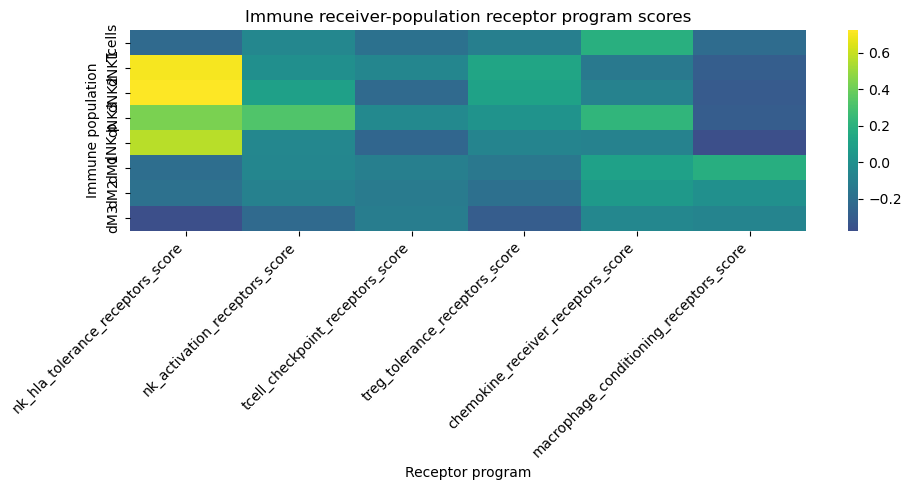

In [39]:
plt.figure(figsize=(10, 5))
sns.heatmap(receiver_receptor_summary, cmap="viridis", center=0)
plt.title("Immune receiver-population receptor program scores")
plt.xlabel("Receptor program")
plt.ylabel("Immune population")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [40]:
program_pairings = {

    "nonclassical_hla_tolerance_score": [
        "nk_hla_tolerance_receptors_score"
    ],

    "checkpoint_inhibitory_score": [
        "tcell_checkpoint_receptors_score",
        "treg_tolerance_receptors_score"
    ],

    "chemokine_recruitment_score": [
        "chemokine_receiver_receptors_score"
    ],

    "cytokine_conditioning_score": [
        "macrophage_conditioning_receptors_score"
    ]
}

In [41]:
compatibility_rows = []

for sender_state in sender_states:
    for receiver_pop in receiver_pops:
        for ligand_score, receptor_scores in program_pairings.items():
            for receptor_score in receptor_scores:

                if (
                    ligand_score in sender_ligand_summary.columns
                    and receptor_score in receiver_receptor_summary.columns
                ):
                    ligand_value = sender_ligand_summary.loc[sender_state, ligand_score]
                    receptor_value = receiver_receptor_summary.loc[receiver_pop, receptor_score]

                    compatibility_rows.append({
                        "sender_state": sender_state,
                        "receiver_population": receiver_pop,
                        "ligand_program": ligand_score.replace("_score", ""),
                        "receptor_program": receptor_score.replace("_score", ""),
                        "ligand_score_mean": ligand_value,
                        "receptor_score_mean": receptor_value,
                        "compatibility_score": ligand_value * receptor_value
                    })

compatibility_df = pd.DataFrame(compatibility_rows)
compatibility_df.head()

,sender_state,receiver_population,ligand_program,receptor_program,ligand_score_mean,receptor_score_mean,compatibility_score
0,VCT,Tcells,nonclassical_hla_tolerance,nk_hla_tolerance_receptors,-0.487937,-0.227143,0.110831
1,VCT,Tcells,checkpoint_inhibitory,tcell_checkpoint_receptors,-0.079895,-0.183870,0.014690
2,VCT,Tcells,checkpoint_inhibitory,treg_tolerance_receptors,-0.079895,-0.102791,0.008213
3,VCT,Tcells,chemokine_recruitment,chemokine_receiver_receptors,-0.003401,0.188239,-0.000640
4,VCT,Tcells,cytokine_conditioning,macrophage_conditioning_receptors,-0.220961,-0.217734,0.048111


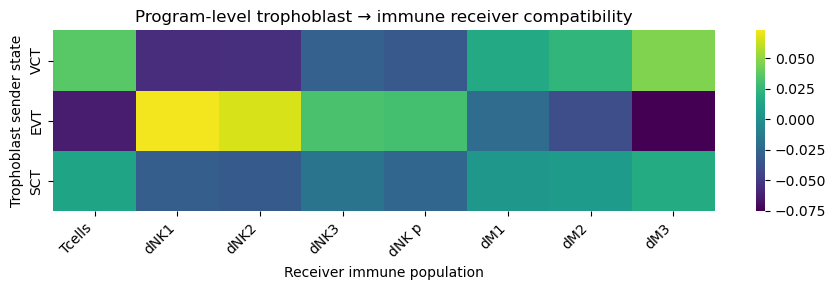

In [42]:
compatibility_matrix = compatibility_df.pivot_table(
    index="sender_state",
    columns="receiver_population",
    values="compatibility_score",
    aggfunc="mean"
).loc[sender_states, receiver_pops]

plt.figure(figsize=(9, 3))
sns.heatmap(compatibility_matrix, cmap="viridis", center=0)
plt.title("Program-level trophoblast → immune receiver compatibility")
plt.xlabel("Receiver immune population")
plt.ylabel("Trophoblast sender state")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

VCT nonclassical HLA score = negative
Tcell NK-HLA receptor score = negative
→ positive compatibility

the math isn't quite matching biology

Because Scanpy gene-program scores can be negative relative to matched background genes, raw ligand × receptor products can produce misleading positive values when both sender and receiver scores are low. For interpretability, sender ligand-program means and receiver receptor-program means were min–max scaled before calculating compatibility scores. The resulting matrix should be interpreted as relative compatibility within the curated program space, not as an absolute measure of signaling strength.

In [43]:
from sklearn.preprocessing import MinMaxScaler

# Scale ligand scores across trophoblast sender states
sender_scaled = sender_ligand_summary.copy()
sender_scaled[:] = MinMaxScaler().fit_transform(sender_scaled)

# Scale receptor scores across immune receiver populations
receiver_scaled = receiver_receptor_summary.copy()
receiver_scaled[:] = MinMaxScaler().fit_transform(receiver_scaled)

In [44]:
compatibility_rows_scaled = []

for sender_state in sender_states:
    for receiver_pop in receiver_pops:
        for ligand_score, receptor_scores in program_pairings.items():
            for receptor_score in receptor_scores:

                if (
                    ligand_score in sender_scaled.columns
                    and receptor_score in receiver_scaled.columns
                ):
                    ligand_value = sender_scaled.loc[sender_state, ligand_score]
                    receptor_value = receiver_scaled.loc[receiver_pop, receptor_score]

                    compatibility_rows_scaled.append({
                        "sender_state": sender_state,
                        "receiver_population": receiver_pop,
                        "ligand_program": ligand_score.replace("_score", ""),
                        "receptor_program": receptor_score.replace("_score", ""),
                        "ligand_score_scaled": ligand_value,
                        "receptor_score_scaled": receptor_value,
                        "compatibility_score_scaled": ligand_value * receptor_value
                    })

compatibility_df_scaled = pd.DataFrame(compatibility_rows_scaled)

In [45]:
compatibility_matrix_scaled = compatibility_df_scaled.pivot_table(
    index="sender_state",
    columns="receiver_population",
    values="compatibility_score_scaled",
    aggfunc="mean"
).loc[sender_states, receiver_pops]

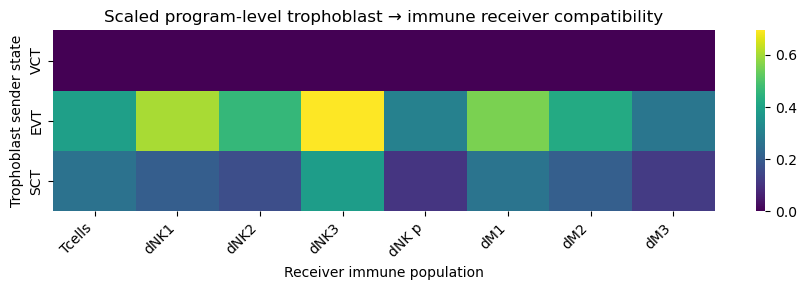

In [46]:
plt.figure(figsize=(9, 3))
sns.heatmap(compatibility_matrix_scaled, cmap="viridis")
plt.title("Scaled program-level trophoblast → immune receiver compatibility")
plt.xlabel("Receiver immune population")
plt.ylabel("Trophoblast sender state")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Within the immune receiver compartment, decidual NK subsets show the strongest receptor compatibility with trophoblast nonclassical HLA/tolerance programs, especially dNK1–dNK3. This recovers the expected EVT–dNK tolerance axis and serves as an internal biological sanity check for the scoring framework.

Macrophage-associated compatibility is not uniformly high across all dM subsets; dM1 shows relatively stronger compatibility than dM2/dM3 in this first-pass analysis. This suggests that trophoblast-associated cytokine/conditioning signals may map onto specific decidual macrophage substates rather than macrophages as a single homogeneous receiver population.

SCT shows weaker but nonzero compatibility with selected immune receiver populations, suggesting that immune-directed signaling is not exclusively EVT-associated, although EVT carries the dominant signal under these curated programs.

what kinds of immune states are associated with the trophoblast signaling environments we identified?


Immune-state programs were defined as small, interpretable transcriptional proxies for activation/effector response, interferon response, cytotoxicity, checkpoint-associated adaptation, Treg-like tolerance, and macrophage inflammatory or remodeling-associated states. These scores are interpreted as relative enrichment of functional transcriptional programs, not direct measurements of immune activity, suppression, exhaustion, or polarization.

In [47]:
immune_state_programs = {

    "activation_effector_response": [
        "CD69",
        "CD38",
        "IFNG"
    ],

    "interferon_response": [
        "ISG15",
        "IFI6",
        "IFIT1",
        "MX1",
        "OAS1",
        "STAT1"
    ],

    "cytotoxicity": [
        "NKG7",
        "PRF1",
        "GZMB",
        "GNLY"
    ],

    "checkpoint_adaptation": [
        "PDCD1",
        "HAVCR2",
        "TOX"
    ],

    "treg_like": [
        "FOXP3",
        "IL2RA",
        "CTLA4",
        "ICOS"
    ],

    "macrophage_inflammatory_state": [
        "IL1B",
        "CXCL8",
        "CCL3"
    ],

    "macrophage_tolerance_remodeling_state": [
        "IL10",
        "TGFB1",
        "MRC1",
        "CD163",
        "C1QA",
        "MAF"
    ]
}

In [48]:
immune_state_programs_found = {}

for program, symbols in immune_state_programs.items():

    genes = [find_gene(g) for g in symbols]
    genes = [g for g in genes if g is not None]

    immune_state_programs_found[program] = genes

    print(program)
    print(genes)
    print()

activation_effector_response
['CD69_ENSG00000110848', 'CD38_ENSG00000004468', 'IFNG_ENSG00000111537']

interferon_response
['ISG15_ENSG00000187608', 'IFI6_ENSG00000126709', 'IFIT1_ENSG00000185745', 'MX1_ENSG00000157601', 'OAS1_ENSG00000089127', 'STAT1_ENSG00000115415']

cytotoxicity
['NKG7_ENSG00000105374', 'PRF1_ENSG00000180644', 'GZMB_ENSG00000100453', 'GNLY_ENSG00000115523']

checkpoint_adaptation
['PDCD1_ENSG00000188389', 'HAVCR2_ENSG00000135077', 'TOX_ENSG00000198846']

treg_like
['FOXP3_ENSG00000049768', 'IL2RA_ENSG00000134460', 'CTLA4_ENSG00000163599', 'ICOS_ENSG00000163600']

macrophage_inflammatory_state
['IL1B_ENSG00000125538', 'CXCL8_ENSG00000169429', 'CCL3_ENSG00000277632']

macrophage_tolerance_remodeling_state
['IL10_ENSG00000136634', 'TGFB1_ENSG00000105329', 'MRC1_ENSG00000260314', 'CD163_ENSG00000177575', 'C1QA_ENSG00000173372', 'MAF_ENSG00000178573']



In [49]:
for program, genes in immune_state_programs_found.items():

    if len(genes) >= 2:

        sc.tl.score_genes(
            immune,
            gene_list=genes,
            score_name=f"{program}_score"
        )

In [50]:
immune_state_score_cols = [
    f"{p}_score"
    for p, genes in immune_state_programs_found.items()
    if len(genes) >= 2
]

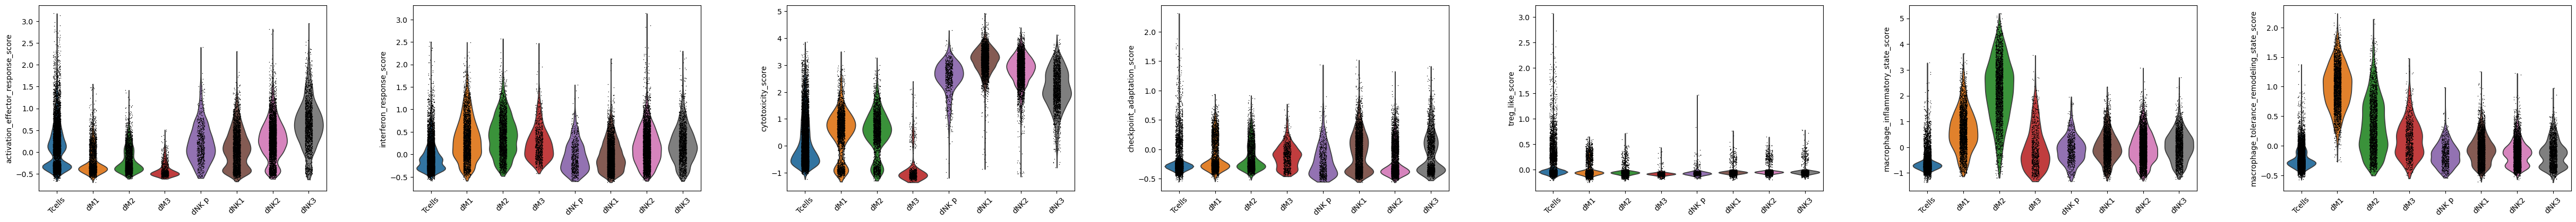

In [51]:
sc.pl.violin(
    immune,
    keys=immune_state_score_cols,
    groupby="CellType",
    rotation=45,
    multi_panel=True
)

Decidual NK subsets showed strong enrichment for cytotoxic-associated programs while retaining high compatibility with trophoblast tolerance-associated signaling, consistent with the specialized, noncanonical functional state of decidual NK cells at the maternal–fetal interface.



In [52]:
immune_state_summary = (
    immune.obs
    .groupby("CellType")[immune_state_score_cols]
    .mean()
)

C:\Users\marga\AppData\Local\Temp\ipykernel_8252\2652683071.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("CellType")[immune_state_score_cols]


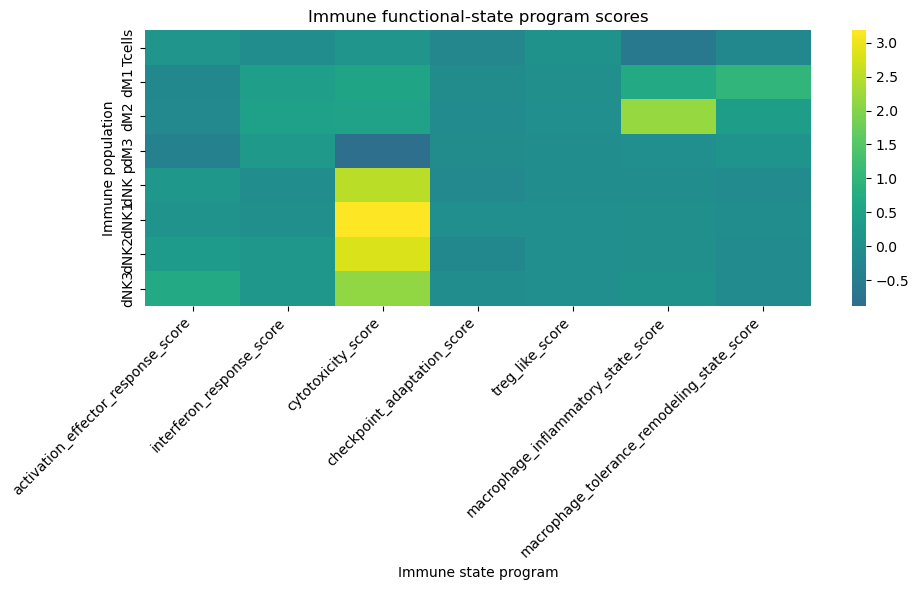

In [53]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    immune_state_summary,
    cmap="viridis",
    center=0
)

plt.title("Immune functional-state program scores")
plt.xlabel("Immune state program")
plt.ylabel("Immune population")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Cytotoxicity is overwhelmingly a dNK feature
especially dNK1/dNK2

T cells carry the strongest checkpoint-adaptation/Treg-like signal
even though the absolute effect sizes are not enormous
the relative enrichment is clean
Macrophage programs separate internally
dM1 strongest inflammatory-state signal
dM2 strongest remodeling/tolerance-associated signal
dM3 comparatively lower for both

Are T cells specifically different from NK/myeloid cells in how they respond?

In [54]:
import sys
print(sys.executable)


c:\Users\marga\anaconda3\envs\scanpy_env\python.exe


In [55]:
immune.obs["immune_lineage"] = immune.obs["CellType"].map({
    "Tcells": "T_cells",
    "dNK1": "NK",
    "dNK2": "NK",
    "dNK3": "NK",
    "dNK p": "NK",
    "dM1": "Macrophage",
    "dM2": "Macrophage",
    "dM3": "Macrophage"
})

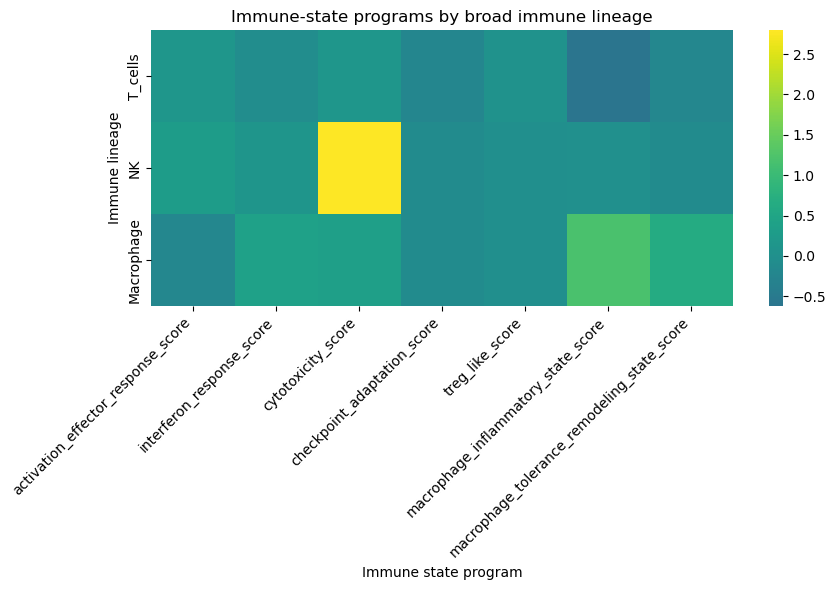

In [56]:
immune_lineage_summary = (
    immune.obs
    .groupby("immune_lineage")[immune_state_score_cols]
    .mean()
    .loc[["T_cells", "NK", "Macrophage"]]
)

plt.figure(figsize=(9, 6))
sns.heatmap(immune_lineage_summary, cmap="viridis", center=0)
plt.title("Immune-state programs by broad immune lineage")
plt.xlabel("Immune state program")
plt.ylabel("Immune lineage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Broad immune-lineage summaries show that NK, T-cell, and macrophage compartments occupy distinct functional-state spaces. NK cells are most enriched for cytotoxicity-associated programs, T cells show comparatively stronger checkpoint-adaptation/Treg-like signatures, and macrophages are distinguished by inflammatory and remodeling-associated programs.

In [57]:
# 1. Which cytotoxicity genes were actually found?
immune_state_programs_found["cytotoxicity"]

['NKG7_ENSG00000105374',
 'PRF1_ENSG00000180644',
 'GZMB_ENSG00000100453',
 'GNLY_ENSG00000115523']

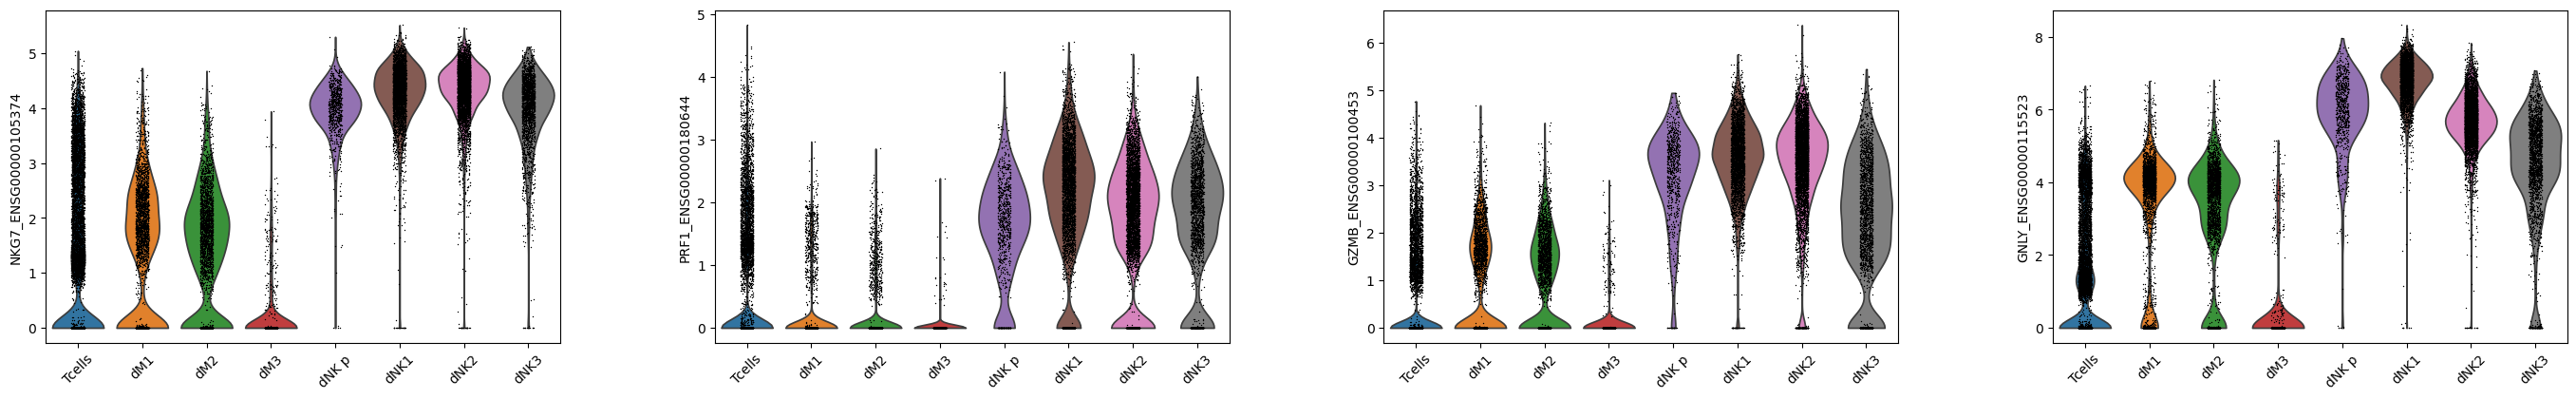

In [58]:
# 2. Individual gene expression by immune lineage / subtype
sc.pl.violin(
    immune,
    keys=immune_state_programs_found["cytotoxicity"],
    groupby="CellType",
    rotation=45,
    multi_panel=True
)

In [59]:
# 3. Does the result survive dropping one gene at a time?
cyto_symbols = ["NKG7", "PRF1", "GZMB", "GNLY"]

for drop_gene in cyto_symbols:
    test_genes = [g for g in cyto_symbols if g != drop_gene]
    found = [find_gene(g) for g in test_genes]
    found = [g for g in found if g is not None]

    sc.tl.score_genes(
        immune,
        gene_list=found,
        score_name=f"cytotoxicity_minus_{drop_gene}_score"
    )

test_cols = [f"cytotoxicity_minus_{g}_score" for g in cyto_symbols]

immune.obs.groupby("immune_lineage")[test_cols].mean()

C:\Users\marga\AppData\Local\Temp\ipykernel_8252\348485476.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  immune.obs.groupby("immune_lineage")[test_cols].mean()


,cytotoxicity_minus_NKG7_score,cytotoxicity_minus_PRF1_score,cytotoxicity_minus_GZMB_score,cytotoxicity_minus_GNLY_score
immune_lineage,,,,
Macrophage,0.345056,0.716002,0.472859,-0.180240
NK,2.648091,3.451062,2.963911,2.111147
T_cells,0.010644,0.277628,0.289983,-0.006587


The cytotoxicity program was checked at the individual-gene level to ensure that the lineage-level signal was not driven by a single marker. NKG7, PRF1, GZMB, and GNLY were each enriched in decidual NK populations relative to T cells and macrophages, supporting the robustness of the cytotoxicity-associated score. This score is interpreted as enrichment of cytotoxic effector machinery rather than direct evidence of cytotoxic activity.

Are tolerogenic signals concentrated in interface-engaged trophoblast states?

In [60]:
tropho_corr_cols = [
    "invasion_evt_score",
    "syncytial_sct_score",
    "progenitor_vct_score",
    "checkpoint_inhibitory_score",
    "nonclassical_hla_tolerance_score",
    "chemokine_recruitment_score",
    "apoptotic_privilege_score",
    "cytokine_conditioning_score"
]

tropho_corr = tropho.obs[tropho_corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(tropho_corr, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Correlation between trophoblast state and ligand programs")
plt.tight_layout()
plt.show()

KeyError: "['invasion_evt_score', 'syncytial_sct_score', 'progenitor_vct_score'] not in index"

immune-regulatory signaling is not evenly distributed but concentrates within programs, particularly within invasion state

EVT/interface state is strongly coupled to tolerogenic ligand programs

but - is EVT just “high everything immune-related,” or are tolerance/inflammatory programs separable?

In [ ]:
#add inflammatory programs

tropho_inflammatory_programs = {
    "trophoblast_interferon_response": [
        "ISG15", "IFI6", "IFIT1", "MX1", "OAS1", "STAT1"
    ],
    "trophoblast_inflammatory_response": [
        "CXCL8", "IL6", "NFKBIA", "TNFAIP3", "JUN", "FOS"
    ]
}

# Find genes present in dataset
tropho_inflammatory_programs_found = {}

for program, symbols in tropho_inflammatory_programs.items():

    genes = [find_gene(g) for g in symbols]
    genes = [g for g in genes if g is not None]

    tropho_inflammatory_programs_found[program] = genes

    print(program)
    print(genes)
    print()

#score programs
for program, genes in tropho_inflammatory_programs_found.items():

    if len(genes) >= 2:

        sc.tl.score_genes(
            tropho,
            gene_list=genes,
            score_name=f"{program}_score"
        )

# define state and signal score columns

state_scores = [
    "invasion_evt_score",
    "syncytial_sct_score",
    "progenitor_vct_score"
]

regulatory_ligand_scores = [
    "checkpoint_inhibitory_score",
    "nonclassical_hla_tolerance_score",
    "chemokine_recruitment_score",
    "apoptotic_privilege_score",
    "cytokine_conditioning_score"
]

inflammatory_scores = [
    "trophoblast_interferon_response_score",
    "trophoblast_inflammatory_response_score"
]

trophoblast_interferon_response
['ISG15_ENSG00000187608', 'IFI6_ENSG00000126709', 'IFIT1_ENSG00000185745', 'MX1_ENSG00000157601', 'OAS1_ENSG00000089127', 'STAT1_ENSG00000115415']

trophoblast_inflammatory_response
['CXCL8_ENSG00000169429', 'IL6_ENSG00000136244', 'NFKBIA_ENSG00000100906', 'TNFAIP3_ENSG00000118503', 'JUN_ENSG00000177606', 'FOS_ENSG00000170345']



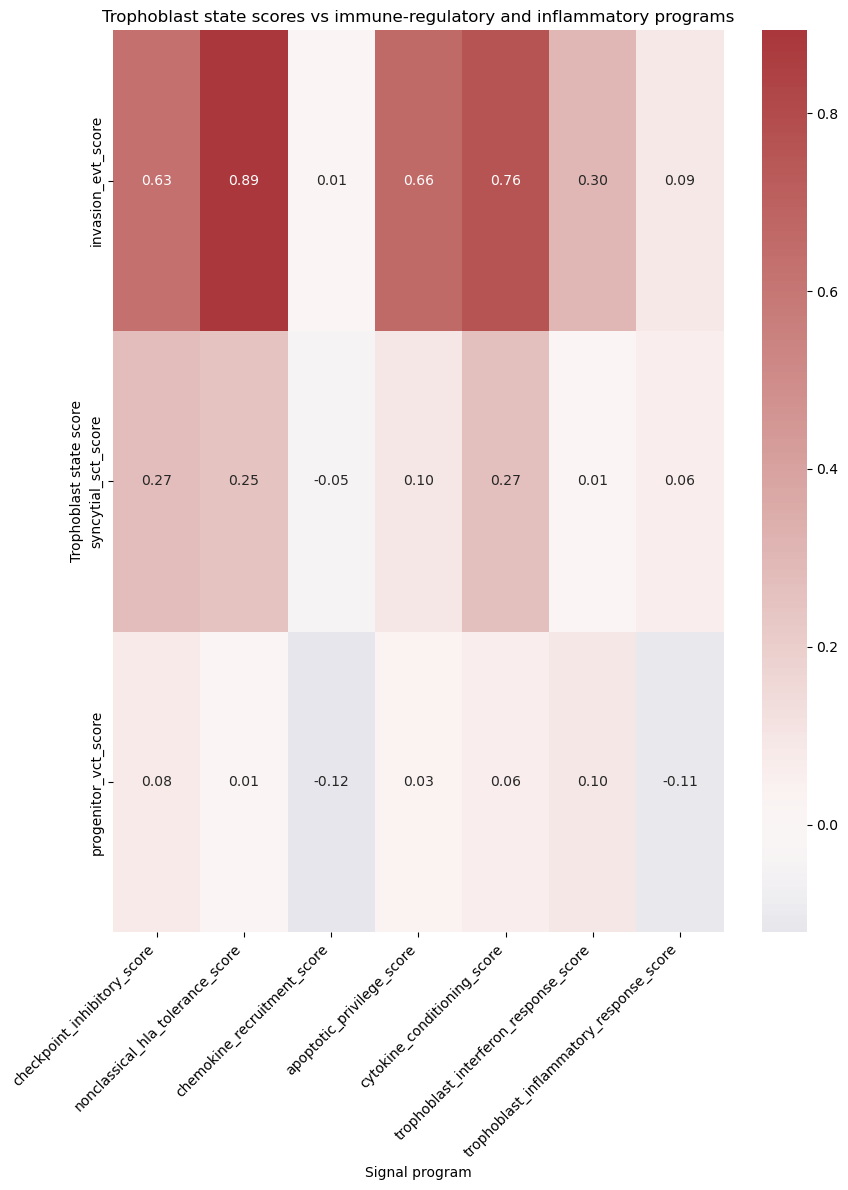

In [ ]:
all_signal_scores = regulatory_ligand_scores + inflammatory_scores

state_signal_corr = (
    tropho.obs[state_scores + all_signal_scores]
    .corr()
    .loc[state_scores, all_signal_scores]
)

plt.figure(figsize=(9, 12))
sns.heatmap(state_signal_corr, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Trophoblast state scores vs immune-regulatory and inflammatory programs")
plt.xlabel("Signal program")
plt.ylabel("Trophoblast state score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Correlation analysis showed that invasive EVT-associated state scores were strongly coupled to multiple immune-regulatory ligand programs, including nonclassical HLA tolerance, checkpoint-associated signaling, cytokine conditioning, and apoptotic-privilege programs. In contrast, EVT state showed only weak association with interferon- and inflammatory-response programs. These results suggest that interface-engaged trophoblast states are specifically associated with coordinated immune-regulatory signaling rather than generalized inflammatory activation.

are immune states real continua inside lineages/subtypes, or just aliases for the cluster labels?


In [ ]:
immune.obs.groupby(
    ["immune_lineage", "CellType"],
    observed=True
)[immune_state_score_cols].mean()

activation_effector_response_score  \
immune_lineage CellType                                       
Macrophage     dM1                                -0.201218   
               dM2                                -0.165954   
               dM3                                -0.404470   
NK             dNK p                               0.203048   
               dNK1                                0.081300   
               dNK2                                0.288744   
               dNK3                                0.647003   
T_cells        Tcells                              0.149390   

                         interferon_response_score  cytotoxicity_score  \
immune_lineage CellType                                                  
Macrophage     dM1                        0.358760            0.527839   
               dM2                        0.415456            0.495028   
               dM3                        0.255499           -0.875150   
NK             dNK p                     -0.052252            2.525023   
               dNK1                      -0.011297            3.180300   
               dNK2                       0.191168            2.821129   
               dNK3                       0.220422            2.111883   
T_cells        Tcells                    -0.060654            0.142917   

                         checkpoint_adaptation_score  treg_like_score  \
immune_lineage CellType                                                 
Macrophage     dM1                         -0.100873         0.004754   
               dM2                         -0.128400        -0.046538   
               dM3                         -0.114654        -0.079834   
NK             dNK p                       -0.190704        -0.057181   
               dNK1                        -0.036131        -0.046674   
               dNK2                        -0.196969        -0.037432   
               dNK3                        -0.053842        -0.030188   
T_cells        Tcells                      -0.228583         0.073292   

                         macrophage_inflammatory_state_score  \
immune_lineage CellType                                        
Macrophage     dM1                                  0.655683   
               dM2                                  2.174829   
               dM3                                 -0.027982   
NK             dNK p                               -0.093008   
               dNK1                                 0.003340   
               dNK2                                -0.010453   
               dNK3                                 0.046375   
T_cells        Tcells                              -0.618219   

                         macrophage_tolerance_remodeling_state_score  
immune_lineage CellType                                               
Macrophage     dM1                                          0.989279  
               dM2                                          0.342567  
               dM3                                          0.115616  
NK             dNK p                                       -0.144541  
               dNK1                                        -0.062568  
               dNK2                                        -0.123515  
               dNK3                                        -0.132633  
T_cells        Tcells                                      -0.210055

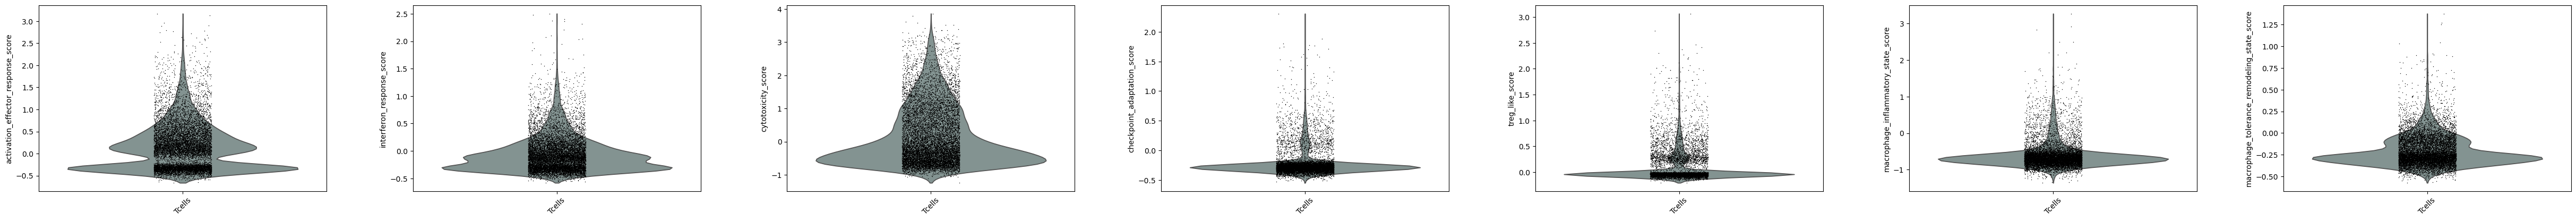

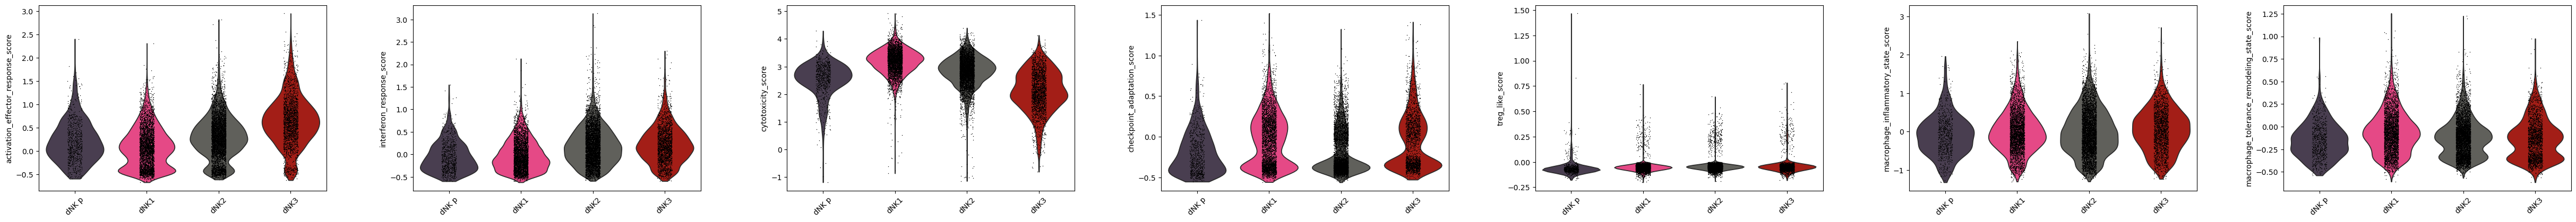

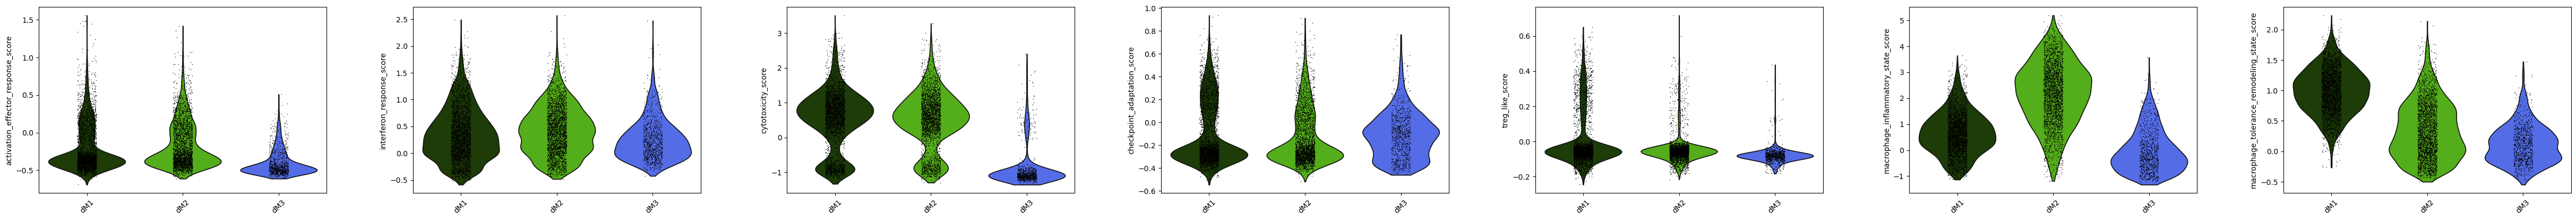

In [ ]:
for lineage in ["T_cells", "NK", "Macrophage"]:
    subset = immune[immune.obs["immune_lineage"] == lineage].copy()
    
    sc.pl.violin(
        subset,
        keys=immune_state_score_cols,
        groupby="CellType",
        rotation=45,
        multi_panel=True
    )

macrophage functional programs appear graded and partially overlapping across decidual macrophage states.


Immune functional-state programs vary both by annotated subtype and continuously within subtypes. While major lineage and subtype distinctions are preserved, substantial within-population heterogeneity remains across activation, cytotoxicity, interferon-response, and remodeling-associated programs.

Can trophoblast state predict immune signaling profile?
First let's fit a simple linear regression model


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
state_scores = [
    "invasion_evt_score",
    "syncytial_sct_score",
    "progenitor_vct_score"
]

signal_scores = [
    "checkpoint_inhibitory_score",
    "nonclassical_hla_tolerance_score",
    "chemokine_recruitment_score",
    "apoptotic_privilege_score",
    "cytokine_conditioning_score",
    "trophoblast_interferon_response_score",
    "trophoblast_inflammatory_response_score"
]

In [ ]:
X = tropho.obs[state_scores].copy()
Y = tropho.obs[signal_scores].copy()

model_results = []

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for signal in signal_scores:
    model = LinearRegression()

    cv_r2 = cross_val_score(
        model,
        X,
        Y[signal],
        cv=cv,
        scoring="r2"
    )

    model.fit(X, Y[signal])

    model_results.append({
        "signal_program": signal,
        "mean_cv_r2": cv_r2.mean(),
        "sd_cv_r2": cv_r2.std(),
        "coef_invasion_evt": model.coef_[0],
        "coef_syncytial_sct": model.coef_[1],
        "coef_progenitor_vct": model.coef_[2],
        "intercept": model.intercept_
    })

model_results_df = pd.DataFrame(model_results)
model_results_df

,signal_program,mean_cv_r2,sd_cv_r2,coef_invasion_evt,coef_syncytial_sct,coef_progenitor_vct,intercept
0,checkpoint_inhibitory_score,0.420309,0.028566,0.141908,0.057728,0.034164,-0.021456
1,nonclassical_hla_tolerance_score,0.804995,0.011075,0.690085,0.049460,-0.157361,-0.107826
2,chemokine_recruitment_score,0.013840,0.017042,0.005083,-0.016663,-0.055289,0.028440
3,apoptotic_privilege_score,0.434623,0.020512,0.263906,-0.034711,-0.046755,0.041513
4,cytokine_conditioning_score,0.594559,0.026901,0.317924,0.075900,0.013442,-0.065001
5,trophoblast_interferon_response_score,0.097645,0.014530,0.088451,-0.019483,0.051957,0.224713
6,trophoblast_inflammatory_response_score,0.020421,0.005371,0.039249,0.017808,-0.144277,0.549430


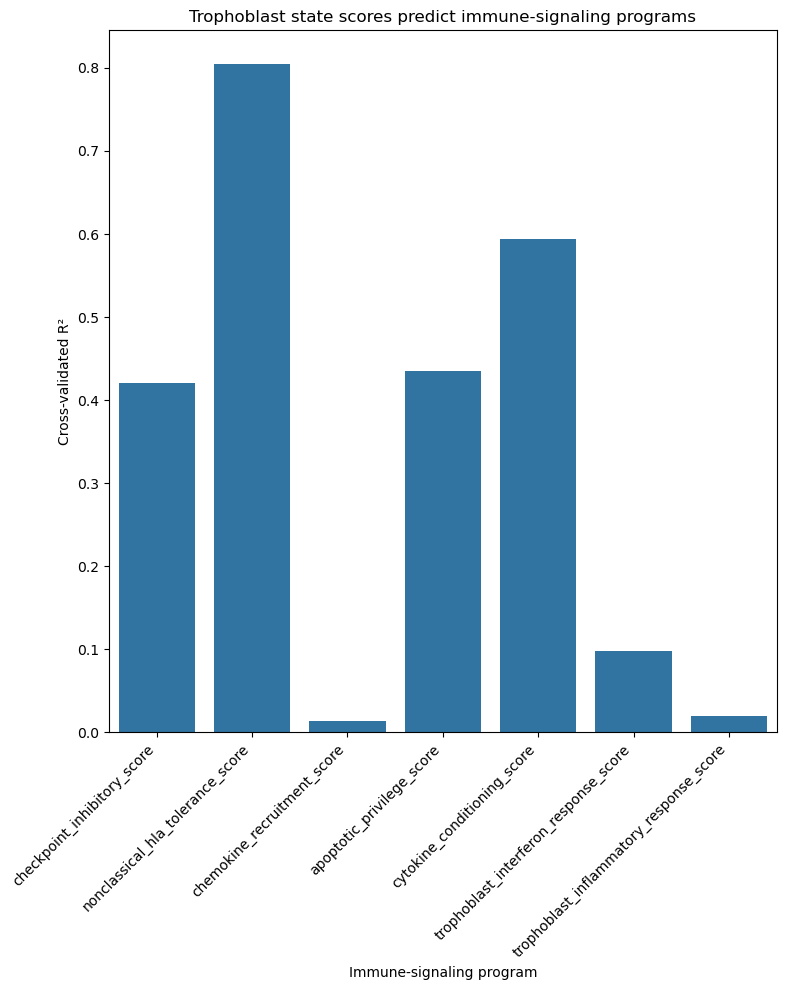

In [ ]:
plt.figure(figsize=(8, 10))

sns.barplot(
    data=model_results_df,
    x="signal_program",
    y="mean_cv_r2"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validated R²")
plt.xlabel("Immune-signaling program")
plt.title("Trophoblast state scores predict immune-signaling programs")
plt.tight_layout()
plt.show()

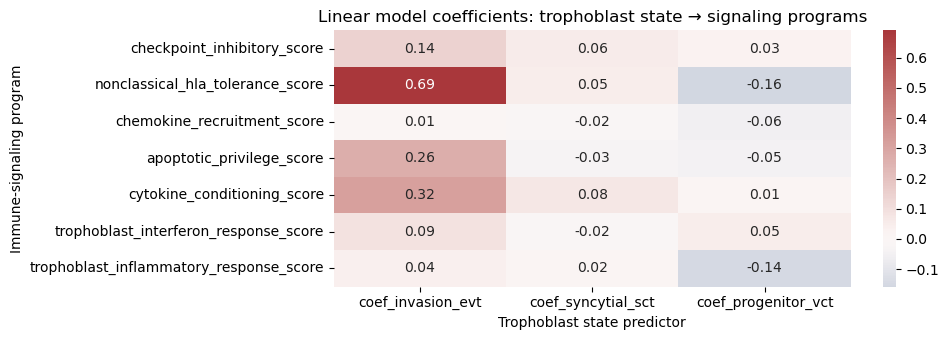

In [ ]:
coef_df = model_results_df.set_index("signal_program")[
    ["coef_invasion_evt", "coef_syncytial_sct", "coef_progenitor_vct"]
]

plt.figure(figsize=(10, 3.5))

sns.heatmap(
    coef_df,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Linear model coefficients: trophoblast state → signaling programs")
plt.xlabel("Trophoblast state predictor")
plt.ylabel("Immune-signaling program")
plt.tight_layout()
plt.show()

Linear modeling supported the correlation-based analysis: invasion/EVT-associated state scores were the dominant positive predictors of immune-regulatory signaling programs, particularly nonclassical HLA tolerance, cytokine conditioning, apoptotic privilege, and checkpoint-associated signaling. In contrast, chemokine recruitment and inflammatory/interferon-response programs were weakly predicted by trophoblast state scores. This supports a model in which interface-engaged trophoblast identity is selectively coupled to immune-regulatory signaling rather than generalized inflammatory activation.